In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

# 設定裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的運算裝置: {device}")

class DeepSpaceDataset(Dataset):
    def __init__(self, npz_folder):
        self.inputs = []
        self.targets = []
        file_paths = glob.glob(os.path.join(npz_folder, "*.npz"))
        
        print(f"🔍 正在載入 {len(file_paths)} 個 .npz 資料檔...")
        for f in file_paths:
            data = np.load(f)
            self.inputs.append(data['inputs'])
            self.targets.append(data['targets'])
            
        self.inputs = np.concatenate(self.inputs, axis=0)
        self.targets = np.concatenate(self.targets, axis=0)
        self.inputs = np.expand_dims(self.inputs, axis=1)
        self.targets = np.expand_dims(self.targets, axis=1)
        print(f"✅ 資料載入完成！總切片數: {self.inputs.shape[0]}")

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)
        y = torch.tensor(self.targets[idx], dtype=torch.float32)
        x = torch.clamp((x - 0.5) * 2.0, -1.0, 1.0)
        y = torch.clamp((y - 0.5) * 2.0, -1.0, 1.0)
        return x, y

DATA_DIR = "processed_dataset"
full_dataset = DeepSpaceDataset(DATA_DIR)

# 切分訓練集與測試集 (80% Train, 20% Test)
dataset_size = len(full_dataset)
test_size = int(0.2 * dataset_size)
train_size = dataset_size - test_size

# 固定亂數種子，確保每次切出來的考卷都一樣
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

print(f"📊 資料集切分: 訓練集 {train_size} 筆, 測試集 {test_size} 筆")

目前使用的運算裝置: cuda
🔍 正在載入 9 個 .npz 資料檔...
✅ 資料載入完成！總切片數: 7133
📊 資料集切分: 訓練集 5707 筆, 測試集 1426 筆


In [2]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        
        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 256)
        self.up3 = UNetUp(512, 128)
        self.up4 = UNetUp(256, 64)
        
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        
        u1 = self.up1(d5, d4)
        u2 = self.up2(u1, d3)
        u3 = self.up3(u2, d2)
        u4 = self.up4(u3, d1)
        return self.final(u4)

class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

# 將大腦放進顯示卡
generator = GeneratorUNet().to(device)
discriminator = Discriminator().to(device)

In [3]:
OUTPUT_BASELINE_DIR = "baseline_cGAN_results"
os.makedirs(OUTPUT_BASELINE_DIR, exist_ok=True)

# 設定優化器與損失函數
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_pixelwise = nn.L1Loss()
lambda_pixel = 100

epochs = 200 

# 動態繪圖函數 (已修正為中立客觀用語)
def show_current_results(test_A, test_B, fake_B, epoch, d_loss, g_loss):
    img_A = test_A[0, 0].cpu().detach().numpy()
    img_B = test_B[0, 0].cpu().detach().numpy()
    img_fake = fake_B[0, 0].cpu().detach().numpy()
    
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Baseline Model Evaluation - Epoch {epoch+1} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}", fontsize=16)
    
    axes[0].imshow(img_A, cmap='magma', origin='lower')
    axes[0].set_title("Input (Degraded)")
    axes[0].axis('off')
    
    axes[1].imshow(img_B, cmap='magma', origin='lower')
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')
    
    axes[2].imshow(img_fake, cmap='magma', origin='lower')
    axes[2].set_title("Generated Output")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

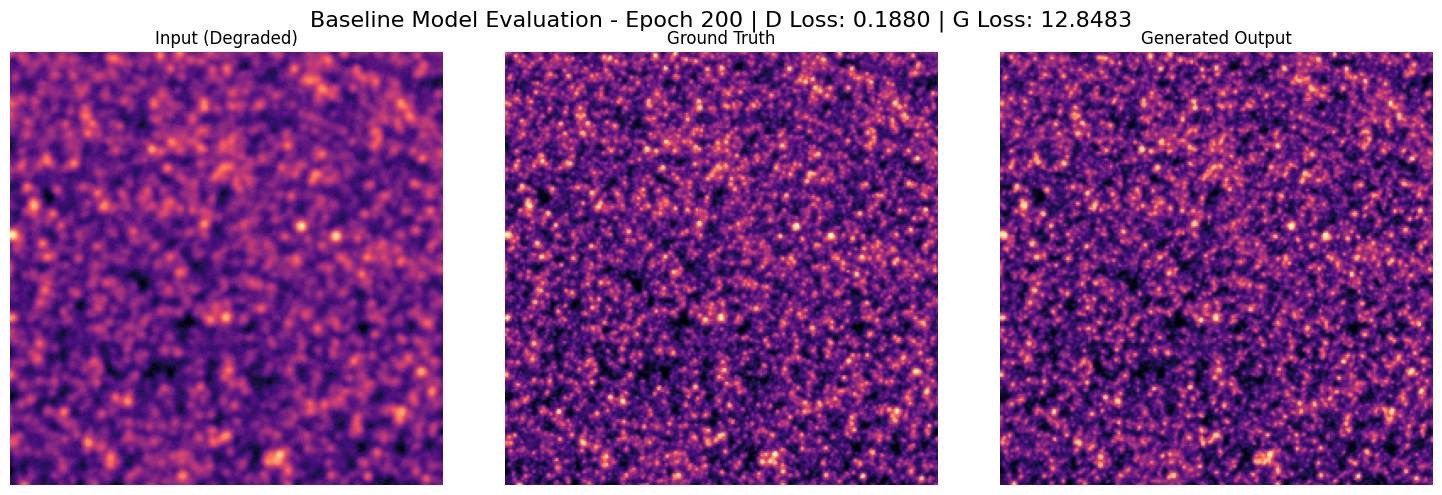

💾 Epoch 200 測試數據與模型權重已儲存。

🎉 基準模型訓練完成！資料與權重皆已封裝完畢。


In [4]:
print("🚀 開始訓練基準 cGAN 模型...")

for epoch in tqdm(range(epochs), desc="Training Progress"):
    
    # --- 訓練階段 ---
    generator.train() # 確保模型處於訓練模式
    discriminator.train()
    
    for i, (real_A, real_B) in enumerate(train_dataloader):
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        # 訓練生成器
        optimizer_G.zero_grad()
        fake_B = generator(real_A)
        
        pred_fake = discriminator(real_A, fake_B)
        valid = torch.ones_like(pred_fake, device=device, requires_grad=False)
        loss_GAN = criterion_GAN(pred_fake, valid)
        
        loss_pixel = criterion_pixelwise(fake_B, real_B)
        loss_G = loss_GAN + lambda_pixel * loss_pixel
        
        loss_G.backward()
        optimizer_G.step()

        # 訓練判別器
        optimizer_D.zero_grad()
        
        pred_real = discriminator(real_A, real_B)
        valid_real = torch.ones_like(pred_real, device=device, requires_grad=False)
        loss_real = criterion_GAN(pred_real, valid_real)
        
        pred_fake_detach = discriminator(real_A, fake_B.detach())
        fake_label = torch.zeros_like(pred_fake_detach, device=device, requires_grad=False)
        loss_fake = criterion_GAN(pred_fake_detach, fake_label)
        
        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    # --- 獨立的測試與驗證階段 (推論模式) ---
    generator.eval() # 關閉 Dropout 並凍結 BatchNorm 統計量
    with torch.no_grad(): # 停止梯度計算，節省記憶體並確保公平測試
        
        # 從測試集抽取一個 Batch 進行驗證
        test_A, test_B = next(iter(test_dataloader))
        test_A = test_A.to(device)
        test_B = test_B.to(device)
        test_fake_B = generator(test_A)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            show_current_results(test_A, test_B, test_fake_B, epoch, loss_D.item(), loss_G.item())
        
        # 僅使用 Test Data 存檔，並同步儲存 .pth 模型權重
        if (epoch + 1) % 40 == 0:
            # 儲存 Numpy 測試陣列
            save_path_npz = os.path.join(OUTPUT_BASELINE_DIR, f"baseline_ep{epoch+1}_test_data.npz")
            np.savez_compressed(save_path_npz, 
                                inputs=test_A.cpu().numpy(), 
                                targets=test_B.cpu().numpy(), 
                                generated=test_fake_B.cpu().numpy())
            
            # 儲存 PyTorch 模型權重
            save_path_pth = os.path.join(OUTPUT_BASELINE_DIR, f"baseline_ep{epoch+1}_weights.pth")
            torch.save(generator.state_dict(), save_path_pth)
            
            print(f"💾 Epoch {epoch+1} 測試數據與模型權重已儲存。")

print("\n🎉 基準模型訓練完成！資料與權重皆已封裝完畢。")

📊 總共載入 16 張測試圖片進行分析...
⚙️ 正在計算空間域指標與頻域 RAPS 特徵...


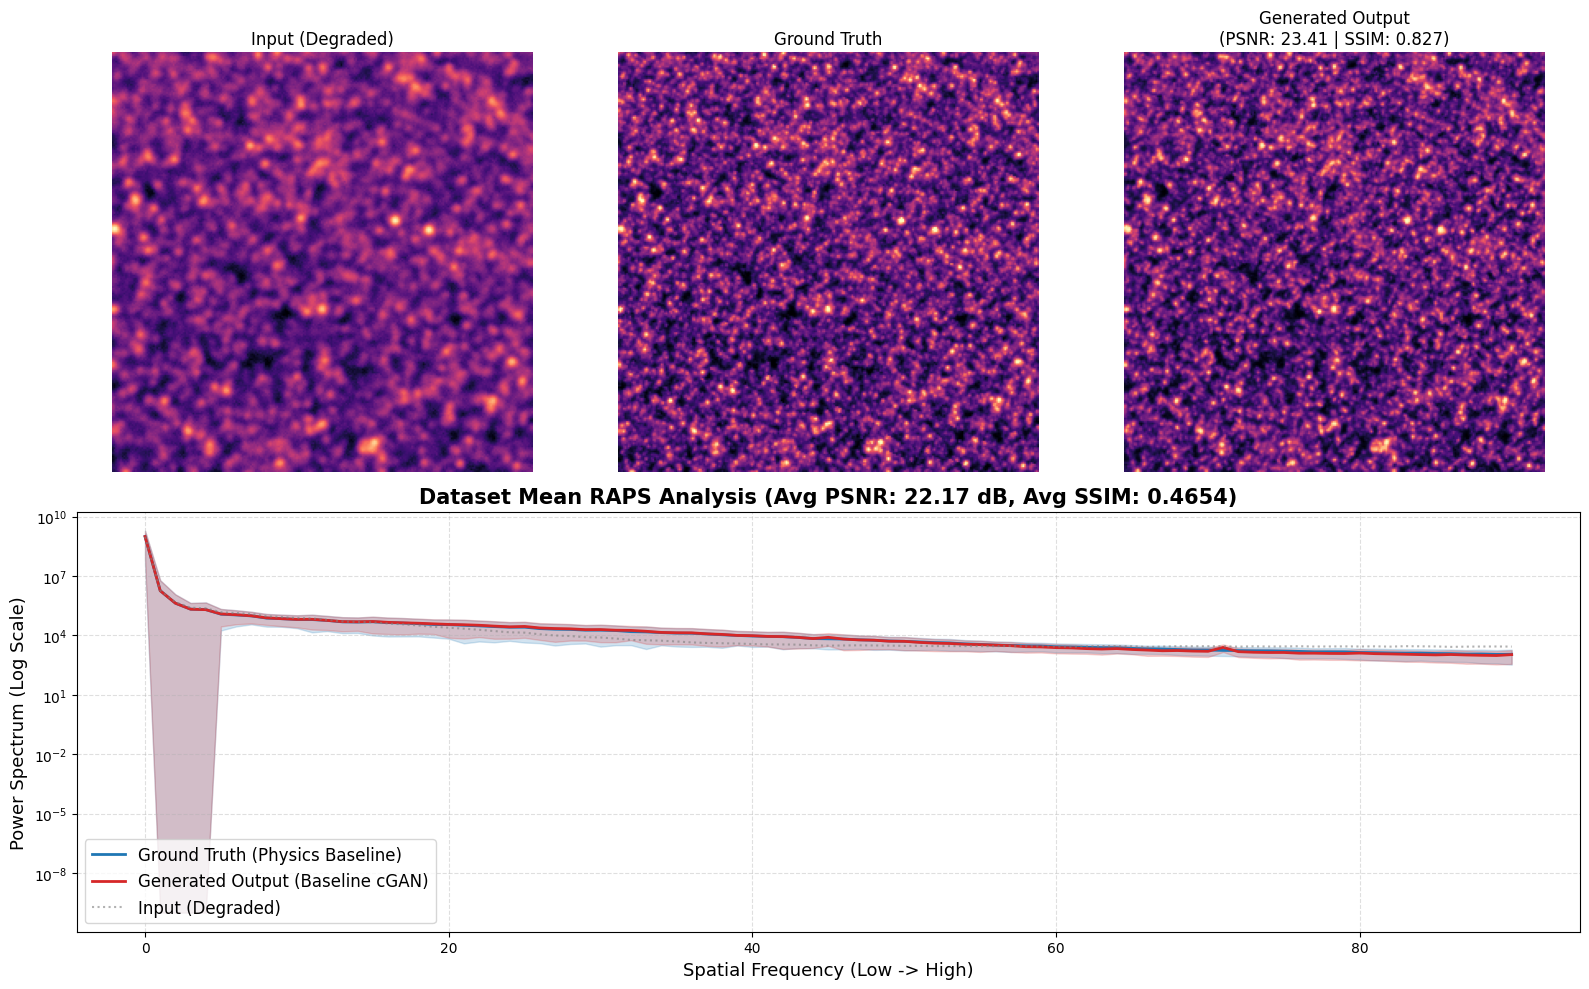

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# 1. 讀取測試集存檔數據
file_path = "baseline_cGAN_results/baseline_ep200_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']

num_images, _, h, w = inputs.shape
print(f"📊 總共載入 {num_images} 張測試圖片進行分析...")

# ==========================================
# 💡 優化：預先計算半徑矩陣 (節省大量迴圈運算時間)
# ==========================================
center = (int(h/2), int(w/2))
y, x = np.indices((h, w))
r_matrix = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)
nr = np.bincount(r_matrix.ravel()) # 每個半徑的像素數量也只要算一次

# ==========================================
# 核心函數：計算單張 RAPS (極速版)
# ==========================================
def calculate_raps_fast(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    power_spectrum = np.abs(f_shift)**2
    
    # 直接使用預先算好的 r_matrix 與 nr
    tbin = np.bincount(r_matrix.ravel(), power_spectrum.ravel())
    radialprofile = tbin / nr
    return radialprofile

# ==========================================
# 2. 計算 RAPS (包含平均與標準差) 與 圖像指標
# ==========================================
all_raps_in, all_raps_gt, all_raps_gen = [], [], []
psnr_gen_list, ssim_gen_list = [], []

print("⚙️ 正在計算空間域指標與頻域 RAPS 特徵...")
for i in range(num_images):
    img_in = inputs[i, 0]
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    # 算 RAPS (使用極速版)
    all_raps_in.append(calculate_raps_fast(img_in))
    all_raps_gt.append(calculate_raps_fast(img_gt))
    all_raps_gen.append(calculate_raps_fast(img_gen))
    
    # 算 PSNR & SSIM (比較 Generate vs Ground Truth)
    # data_range=2.0 是完全正確的！因為你的數值在 [-1, 1] 之間
    psnr_val = psnr(img_gt, img_gen, data_range=2.0)
    ssim_val = ssim(img_gt, img_gen, data_range=2.0)
    psnr_gen_list.append(psnr_val)
    ssim_gen_list.append(ssim_val)

# 跨圖片取 RAPS 平均與標準差
mean_raps_in = np.mean(all_raps_in, axis=0)
mean_raps_gt = np.mean(all_raps_gt, axis=0)
mean_raps_gen = np.mean(all_raps_gen, axis=0)

std_raps_gt = np.std(all_raps_gt, axis=0)
std_raps_gen = np.std(all_raps_gen, axis=0)

# 取前半段有效頻率區間 (Nyquist Frequency)
freq_len = len(mean_raps_gt) // 2
x_freq = np.arange(freq_len)

# 圖像指標平均
mean_psnr = np.mean(psnr_gen_list)
mean_ssim = np.mean(ssim_gen_list)

# ==========================================
# 繪圖視覺化 (發表級別圖表)
# ==========================================
fig = plt.figure(figsize=(16, 10))

# [上排] 空間域對比 (挑選一張展示)
display_idx = 0 
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(inputs[display_idx, 0], cmap='magma', origin='lower')
ax1.set_title(f"Input (Degraded)")
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
ax2.imshow(targets[display_idx, 0], cmap='magma', origin='lower')
ax2.set_title(f"Ground Truth")
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(generated[display_idx, 0], cmap='magma', origin='lower')
ax3.set_title(f"Generated Output\n(PSNR: {psnr_gen_list[display_idx]:.2f} | SSIM: {ssim_gen_list[display_idx]:.3f})")
ax3.axis('off')

# [下排] 頻率域 RAPS 加上不確定值 (Error Band)
ax4 = plt.subplot(2, 1, 2)

# 畫出 Ground Truth 的平均線與誤差陰影
ax4.plot(x_freq, mean_raps_gt[:freq_len], label='Ground Truth (Physics Baseline)', linewidth=2, color='#1f77b4')
ax4.fill_between(x_freq, 
                 np.maximum(mean_raps_gt[:freq_len] - std_raps_gt[:freq_len], 1e-10), 
                 mean_raps_gt[:freq_len] + std_raps_gt[:freq_len], 
                 color='#1f77b4', alpha=0.2)

# 畫出 cGAN 的平均線與誤差陰影
ax4.plot(x_freq, mean_raps_gen[:freq_len], label='Generated Output (Baseline cGAN)', linewidth=2, color='#d62728')
ax4.fill_between(x_freq, 
                 np.maximum(mean_raps_gen[:freq_len] - std_raps_gen[:freq_len], 1e-10), 
                 mean_raps_gen[:freq_len] + std_raps_gen[:freq_len], 
                 color='#d62728', alpha=0.2)

# 畫出 Input 參考線
ax4.plot(x_freq, mean_raps_in[:freq_len], label='Input (Degraded)', alpha=0.6, linestyle=':', color='gray')

ax4.set_yscale('log')
ax4.set_title(f"Dataset Mean RAPS Analysis (Avg PSNR: {mean_psnr:.2f} dB, Avg SSIM: {mean_ssim:.4f})", fontsize=15, fontweight='bold')
ax4.set_xlabel("Spatial Frequency (Low -> High)", fontsize=13)
ax4.set_ylabel("Power Spectrum (Log Scale)", fontsize=13)
ax4.legend(fontsize=12, loc='lower left')
ax4.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

⚙️ 正在計算傅立葉相位誤差與局部光通量守恆...


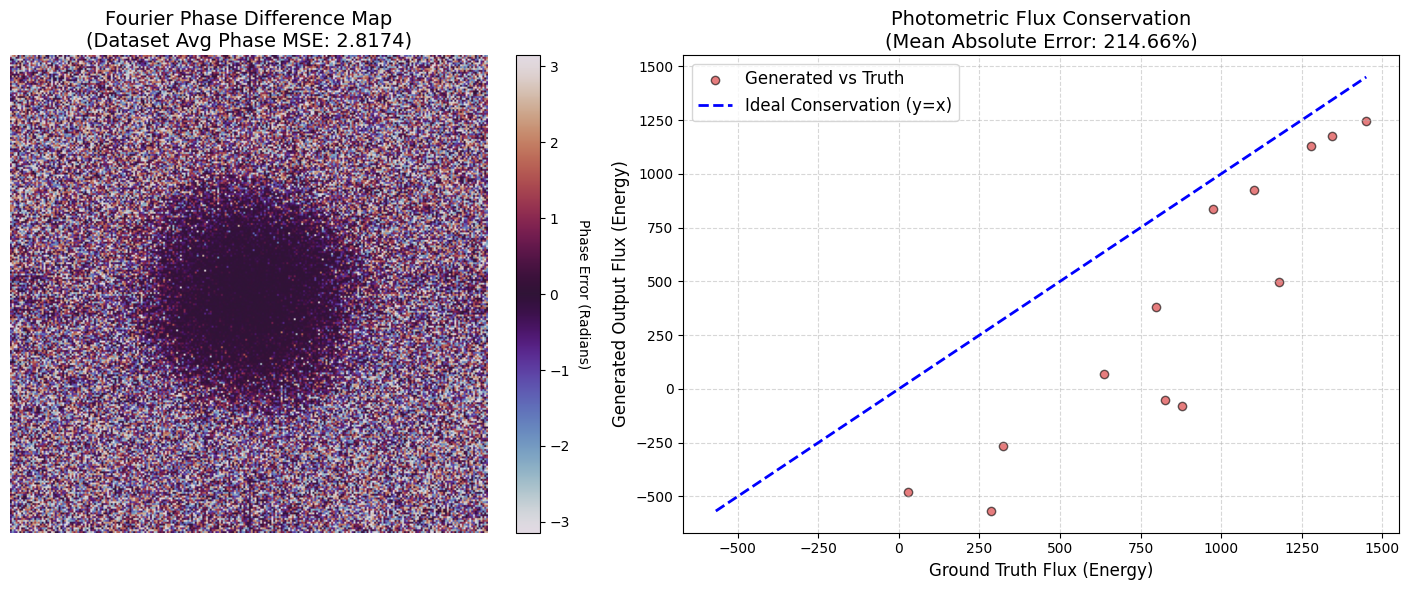

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 讀取測試集存檔數據
file_path = "baseline_cGAN_results/baseline_ep200_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']
num_images = inputs.shape[0]

print("⚙️ 正在計算傅立葉相位誤差與局部光通量守恆...")

# ==========================================
# 分析一：傅立葉相位誤差 (Fourier Phase Error)
# ==========================================
def calculate_phase(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    # 取出相位角 (介於 -pi 到 pi 之間)
    return np.angle(f_shift)

phase_mse_list = []
for i in range(num_images):
    phase_gt = calculate_phase(targets[i, 0])
    phase_gen = calculate_phase(generated[i, 0])
    
    # 計算相位差 (必須處理圓周纏繞 wrap-around 的問題，例如 pi 與 -pi 其實是同一點)
    phase_diff = np.angle(np.exp(1j * (phase_gt - phase_gen)))
    # 計算相位均方誤差 (Phase MSE)
    phase_mse = np.mean(phase_diff**2)
    phase_mse_list.append(phase_mse)

mean_phase_mse = np.mean(phase_mse_list)

# ==========================================
# 分析二：光通量測光守恆 (Flux Conservation / Photometry)
# ==========================================
flux_gt_list = []
flux_gen_list = []

for i in range(num_images):
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    # 建立「星體遮罩 (Mask)」：取 Ground Truth 中亮度前 5% 的像素作為星體區域
    threshold = np.percentile(img_gt, 95)
    star_mask = img_gt > threshold
    
    # 分別計算這些星體區域內的「總光通量 (像素加總)」
    flux_gt = np.sum(img_gt[star_mask])
    flux_gen = np.sum(img_gen[star_mask])
    
    # 避免極端小數值除以零，加入微小保護值
    if flux_gt > 1e-5:
        flux_gt_list.append(flux_gt)
        flux_gen_list.append(flux_gen)

flux_gt_arr = np.array(flux_gt_list)
flux_gen_arr = np.array(flux_gen_list)

# 計算平均絕對百分比誤差 (MAPE)
flux_mape = np.mean(np.abs(flux_gt_arr - flux_gen_arr) / flux_gt_arr) * 100

# ==========================================
# 繪圖視覺化 (發布級圖表)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [左圖] 相位差異分佈地圖 (取第一張圖展示)
display_idx = 0
phase_gt_sample = calculate_phase(targets[display_idx, 0])
phase_gen_sample = calculate_phase(generated[display_idx, 0])
phase_diff_sample = np.angle(np.exp(1j * (phase_gt_sample - phase_gen_sample)))

im1 = axes[0].imshow(phase_diff_sample, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0].set_title(f"Fourier Phase Difference Map\n(Dataset Avg Phase MSE: {mean_phase_mse:.4f})", fontsize=14)
axes[0].axis('off')
cbar = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Phase Error (Radians)', rotation=270, labelpad=15)

# [右圖] 測光一致性散佈圖 (Photometry Scatter Plot)
axes[1].scatter(flux_gt_arr, flux_gen_arr, alpha=0.6, color='#d62728', edgecolors='k', label='Generated vs Truth')

# 畫出理想的 y = x 對角線 (光通量 100% 守恆線)
max_flux = max(np.max(flux_gt_arr), np.max(flux_gen_arr))
min_flux = min(np.min(flux_gt_arr), np.min(flux_gen_arr))
axes[1].plot([min_flux, max_flux], [min_flux, max_flux], 'b--', linewidth=2, label='Ideal Conservation (y=x)')

axes[1].set_title(f"Photometric Flux Conservation\n(Mean Absolute Error: {flux_mape:.2f}%)", fontsize=14)
axes[1].set_xlabel("Ground Truth Flux (Energy)", fontsize=12)
axes[1].set_ylabel("Generated Output Flux (Energy)", fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 1. 讀取測試集存檔數據
# ==========================================
file_path = "baseline_cGAN_results/baseline_ep200_test_data.npz"
data = np.load(file_path)

inputs = data['inputs']
targets = data['targets']
generated = data['generated']
num_images = inputs.shape[0]

print(f"📦 成功載入 {num_images} 張圖片，準備開始數據萃取...")

# 用來存放每一張圖的計算結果
all_metrics = []

# ==========================================
# 2. 開始逐張計算所有核心科學指標
# ==========================================
for i in range(num_images):
    img_in = inputs[i, 0]
    img_gt = targets[i, 0]
    img_gen = generated[i, 0]
    
    # --- 指標 A: 傳統影像還原度 (PSNR & SSIM) ---
    psnr_val = psnr(img_gt, img_gen, data_range=2.0)
    ssim_val = ssim(img_gt, img_gen, data_range=2.0)
    
    # --- 指標 B: 傅立葉相位誤差 (Phase MSE) ---
    phase_gt = np.angle(np.fft.fftshift(np.fft.fft2(img_gt)))
    phase_gen = np.angle(np.fft.fftshift(np.fft.fft2(img_gen)))
    phase_diff = np.angle(np.exp(1j * (phase_gt - phase_gen)))
    phase_mse = np.mean(phase_diff**2)
    
    # --- 指標 C: 局部光通量守恆 (Flux Conservation) ---
    threshold = np.percentile(img_gt, 95)
    star_mask = img_gt > threshold
    
    flux_gt = np.sum(img_gt[star_mask])
    flux_gen = np.sum(img_gen[star_mask])
    
    # 計算單張的光通量誤差百分比 (避免除以零)
    if flux_gt > 1e-5:
        flux_error_percent = np.abs(flux_gt - flux_gen) / flux_gt * 100
    else:
        flux_error_percent = np.nan # 如果那張圖剛好全黑，標記為 NaN
        
    # 將這張圖的所有數據打包成字典
    all_metrics.append({
        "Image_ID": f"Test_Sample_{i:02d}",
        "PSNR (dB)": round(psnr_val, 4),
        "SSIM": round(ssim_val, 4),
        "Phase_MSE (rad)": round(phase_mse, 4),
        "GT_Flux (Energy)": round(flux_gt, 2),
        "Gen_Flux (Energy)": round(flux_gen, 2),
        "Flux_Error (%)": round(flux_error_percent, 2)
    })

# ==========================================
# 3. 轉換為 Pandas 表格並計算整體平均
# ==========================================
df_metrics = pd.DataFrame(all_metrics)

# 計算所有欄位的平均值 (忽略 NaN)，並作為新的一行加入底部
mean_values = df_metrics.mean(numeric_only=True).round(4)
mean_row = pd.DataFrame([mean_values])
mean_row.insert(0, "Image_ID", "DATASET_AVERAGE")

# 合併單張數據與平均值
df_final = pd.concat([df_metrics, mean_row], ignore_index=True)

# ==========================================
# 4. 匯出為 CSV 報表
# ==========================================
output_csv_path = "baseline_cGAN_results/baseline_metrics_report.csv"
df_final.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

print(f"✅ 萃取完成！所有數據已成功匯出至：{output_csv_path}")

# 在終端機預覽一下前幾筆資料
print("\n📊 數據報表預覽：")
print(df_final.head())

📦 成功載入 16 張圖片，準備開始數據萃取...
✅ 萃取完成！所有數據已成功匯出至：baseline_cGAN_results/baseline_metrics_report.csv

📊 數據報表預覽：
         Image_ID  PSNR (dB)    SSIM  Phase_MSE (rad)  GT_Flux (Energy)  \
0  Test_Sample_00    23.4053  0.8273           2.4782       1449.949951   
1  Test_Sample_01    23.9422  0.8439           2.3439       1343.430054   
2  Test_Sample_02    17.7707  0.1204           3.1165        824.510010   
3  Test_Sample_03    21.4693  0.5305           2.8627        798.010010   
4  Test_Sample_04    20.2531  0.1842           3.1012        -77.930000   

   Gen_Flux (Energy)  Flux_Error (%)  
0        1245.489990       14.100000  
1        1173.489990       12.650000  
2         -49.700001      106.029999  
3         382.070007       52.119999  
4        -670.099976             NaN  
